<a href="https://colab.research.google.com/github/seghirabderrahim/quadbot/blob/main/EMS_PPO_Colab_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔋 Deep Reinforcement Learning Energy Management System (EMS)
### Algorithm: PPO (Stable-Baselines3) | Hybrid Microgrid Battery Dispatch
---
**Sections**
- **A** – Installation & Setup  
- **B** – Robust Data Pipeline  
- **C** – Custom Gymnasium Environment (`MicrogridEnv`)  
- **D** – Heuristic Rule-Based Baseline Controller  
- **E** – PPO Model Training  
- **F** – Deterministic Evaluation & Comparative Analysis  
- **G** – Thesis-Ready Visualisations  


## Block A │ Installation & Setup

In [ ]:
# Install required packages (uncomment on first run in Colab)
!pip install -q stable-baselines3[extra] gymnasium pandas numpy matplotlib

import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

warnings.filterwarnings("ignore")

# ── Deterministic seeds ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("✅  Block A complete – libraries loaded, seeds fixed.")


✅  Block A complete – libraries loaded, seeds fixed.


## Block B │ Robust Data Pipeline

In [ ]:
# ── Toggle: True → synthetic data, False → upload your CSV ──
USE_DUMMY_DATA = False           # ← change to False for real data
CSV_FILENAME   = "dataset.csv"  # used only when USE_DUMMY_DATA = False

N_ROWS = 5_000  # synthetic dataset size (hourly rows)

# ── B-1  Data acquisition ────────────────────────────────────
if USE_DUMMY_DATA:
    print("ℹ️   Generating synthetic dataset …")

    rng   = np.random.default_rng(SEED)
    hours = np.arange(N_ROWS) % 24
    day_idx = np.arange(N_ROWS) // 24

    # Realistic solar profile (bell curve around noon, zero at night)
    solar_base = np.maximum(0, np.sin(np.pi * (hours - 6) / 12))
    solar_pv   = solar_base * rng.uniform(80, 120, N_ROWS) + rng.normal(0, 3, N_ROWS)
    solar_pv   = np.clip(solar_pv, 0, None)

    # Wind with mild diurnal pattern + noise
    wind_base  = 30 + 20 * np.sin(2 * np.pi * hours / 24 + np.pi)
    wind_power = wind_base + rng.normal(0, 8, N_ROWS)
    wind_power = np.clip(wind_power, 0, None)

    # Load demand (morning & evening peaks)
    load_base  = (60
                  + 30 * np.exp(-((hours - 8) ** 2) / 8)
                  + 40 * np.exp(-((hours - 19) ** 2) / 6))
    grid_load  = load_base + rng.normal(0, 5, N_ROWS)
    grid_load  = np.clip(grid_load, 20, None)

    # Meteorological
    irradiance = solar_base * rng.uniform(900, 1100, N_ROWS)
    wind_speed = rng.uniform(3, 12, N_ROWS)
    temperature= 20 + 10 * np.sin(np.pi * (hours - 6) / 12) + rng.normal(0, 2, N_ROWS)
    humidity   = rng.uniform(40, 90, N_ROWS)
    pressure   = rng.uniform(1010, 1025, N_ROWS)

    # Battery SoC (historical – NOT used by agent, kept for schema completeness)
    battery_soc = rng.uniform(20, 80, N_ROWS)

    # Forecasts (add small noise to actuals)
    pred_solar = solar_pv   + rng.normal(0, 4, N_ROWS)
    pred_wind  = wind_power + rng.normal(0, 3, N_ROWS)
    pred_total = pred_solar + pred_wind

    df = pd.DataFrame({
        "solar_pv_output"            : solar_pv,
        "wind_power_output"          : wind_power,
        "grid_load_demand"           : grid_load,
        "solar_irradiance"           : irradiance,
        "wind_speed"                 : wind_speed,
        "temperature"                : temperature,
        "humidity"                   : humidity,
        "atmospheric_pressure"       : pressure,
        "battery_state_of_charge"    : battery_soc,
        "hour_of_day"                : hours.astype(int),
        "day_of_week"                : (day_idx % 7).astype(int),
        "predicted_solar_pv_output"  : np.clip(pred_solar, 0, None),
        "predicted_wind_power_output": np.clip(pred_wind,  0, None),
        "total_predicted_energy"     : np.clip(pred_total, 0, None),
    })

else:
    print("⬆️   Please upload your CSV file …")
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(list(uploaded.keys())[0])

print(f"   Dataset shape: {df.shape}")
print(f"   Columns      : {list(df.columns)}\n")


⬆️   Please upload your CSV file …


Saving Renewable_energy_dataset.csv to Renewable_energy_dataset.csv
   Dataset shape: (3546, 21)
   Columns      : ['timestamp', 'solar_pv_output', 'wind_power_output', 'total_renewable_energy', 'solar_irradiance', 'wind_speed', 'temperature', 'humidity', 'atmospheric_pressure', 'grid_load_demand', 'frequency', 'voltage', 'power_exchange', 'battery_state_of_charge', 'battery_charging_rate', 'battery_discharging_rate', 'hour_of_day', 'day_of_week', 'predicted_solar_pv_output', 'predicted_wind_power_output', 'total_predicted_energy']



In [ ]:
# ── B-2  Time-of-Use pricing ─────────────────────────────────
def assign_tou_price(hour: int) -> float:
    """
    Three-tier Time-of-Use electricity price based on hour of day.
      Night off-peak  22:00 – 06:00  →  0.08 $/kWh
      Standard day    06:00 – 16:00  →  0.15 $/kWh
      Evening peak    16:00 – 22:00  →  0.25 $/kWh
    """
    if   hour >= 22 or hour < 6:  return 0.08
    elif hour < 16:               return 0.15
    else:                         return 0.25

df["price_actual"] = df["hour_of_day"].apply(assign_tou_price)

# ── B-3  Cyclical encoding of hour_of_day ────────────────────
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

# ── B-4  Min-Max normalisation of forecast / price features ──
NORM_COLS = [
    "predicted_solar_pv_output",
    "predicted_wind_power_output",
    "grid_load_demand",
    "price_actual",
]
norm_stats: dict = {}
for col in NORM_COLS:
    col_min = df[col].min()
    col_max = df[col].max()
    norm_stats[col] = (col_min, col_max)
    denom = col_max - col_min
    df[f"{col}_norm"] = (df[col] - col_min) / (denom if denom > 1e-8 else 1.0)

# ── B-5  Chronological 80 / 20 split ─────────────────────────
split_idx = int(len(df) * 0.80)
df_train  = df.iloc[:split_idx].reset_index(drop=True)
df_test   = df.iloc[split_idx:].reset_index(drop=True)

print(f"✅  Block B complete – train: {len(df_train)} rows | test: {len(df_test)} rows")


✅  Block B complete – train: 2836 rows | test: 710 rows


## Block C │ Custom Gymnasium Environment

In [ ]:
class MicrogridEnv(gym.Env):
    """
    Single-node hybrid microgrid environment for EMS optimisation.

    Observation (7-dim):
        [SoC_norm, pred_solar_norm, pred_wind_norm,
         pred_load_norm, price_norm, hour_sin, hour_cos]

    Action (1-dim, continuous [-1, 1]):
        -1 → maximum discharging  |  +1 → maximum charging

    Reward:
        Economics (grid trade cash-flow)
        + Arbitrage bonus (discharge at peak / charge at off-peak)
        - Battery wear penalty (reduced to encourage dispatch)
        - SoC safety violation penalty (quadratic)
        All divided by 100 for PPO training stability.
    """

    metadata = {"render_modes": []}

    # ── Battery physical parameters ───────────────────────────
    BAT_CAPACITY_KWH  = 500.0   # kWh
    BAT_MAX_POWER_KW  = 100.0   # kW  (charge / discharge limit)
    BAT_EFFICIENCY    = 0.95    # one-way efficiency
    SOC_MIN           = 0.20    # 20 %
    SOC_MAX           = 0.80    # 80 %
    SOC_INIT          = 0.50    # starting state
    DT                = 1.0     # timestep hours

    # ── Reward hyper-parameters ───────────────────────────────
    WEAR_COST_PER_KWH = 0.001   # $/kWh throughput wear (reduced to encourage dispatch)
    SOC_PENALTY_SCALE = 5.0     # quadratic violation weight
    EXPORT_DISCOUNT   = 0.80    # sell at 80 % of retail price
    PEAK_PRICE        = 0.25    # used for arbitrage bonus
    OFFPEAK_PRICE     = 0.08    # used for arbitrage bonus

    def __init__(self, data: pd.DataFrame):
        super().__init__()
        self.data    = data.reset_index(drop=True)
        self.n_steps = len(self.data)

        low  = np.array([0, 0, 0, 0, 0, -1, -1], dtype=np.float32)
        high = np.array([1, 1, 1, 1, 1,  1,  1], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)
        self.action_space = spaces.Box(
            low=np.array([-1.0], dtype=np.float32),
            high=np.array([ 1.0], dtype=np.float32),
            dtype=np.float32,
        )
        self._reset_state()

    def _reset_state(self):
        self.current_step      = 0
        self.soc               = self.SOC_INIT
        self.cumulative_reward = 0.0

    def _get_obs(self) -> np.ndarray:
        # Clamp index so we never go out of bounds after episode ends
        idx = min(self.current_step, self.n_steps - 1)
        row = self.data.iloc[idx]
        obs = np.array([
            self.soc,
            float(row["predicted_solar_pv_output_norm"]),
            float(row["predicted_wind_power_output_norm"]),
            float(row["grid_load_demand_norm"]),
            float(row["price_actual_norm"]),
            float(row["hour_sin"]),
            float(row["hour_cos"]),
        ], dtype=np.float32)
        return np.clip(obs, -1, 1)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_state()
        return self._get_obs(), {}

    def step(self, action: np.ndarray):
        row = self.data.iloc[min(self.current_step, self.n_steps - 1)]

        # 1. Decode action → battery power request (kW)
        action_scalar = float(np.clip(action[0], -1.0, 1.0))
        bat_power_req = action_scalar * self.BAT_MAX_POWER_KW

        # 2. Apply efficiency & SoC constraints
        if bat_power_req >= 0:
            # Charging
            soc_headroom_kwh  = (self.SOC_MAX - self.soc) * self.BAT_CAPACITY_KWH
            actual_charge_kwh = max(0.0, min(
                bat_power_req * self.DT * self.BAT_EFFICIENCY,
                soc_headroom_kwh
            ))
            self.soc         += actual_charge_kwh / self.BAT_CAPACITY_KWH
            bat_actual_power  = actual_charge_kwh / (self.DT * self.BAT_EFFICIENCY)
        else:
            # Discharging
            soc_avail_kwh        = (self.soc - self.SOC_MIN) * self.BAT_CAPACITY_KWH
            discharge_req_kwh    = abs(bat_power_req) * self.DT
            actual_discharge_kwh = max(0.0, min(
                discharge_req_kwh / self.BAT_EFFICIENCY,
                soc_avail_kwh
            ))
            energy_to_grid_kwh = actual_discharge_kwh * self.BAT_EFFICIENCY
            self.soc          -= actual_discharge_kwh / self.BAT_CAPACITY_KWH
            bat_actual_power   = -(energy_to_grid_kwh / self.DT)

        self.soc = float(np.clip(self.soc, 0.0, 1.0))

        # 3. Grid power balance
        solar_actual = float(row["solar_pv_output"])
        wind_actual  = float(row["wind_power_output"])
        load_actual  = float(row["grid_load_demand"])
        price        = float(row["price_actual"])
        net_load_kw  = load_actual - (solar_actual + wind_actual) + bat_actual_power

        # 4. Economic reward (negative = cost, positive = revenue)
        if net_load_kw > 0:
            economics = -net_load_kw * self.DT * price
        else:
            economics = -net_load_kw * self.DT * price * self.EXPORT_DISCOUNT

        # 4b. Arbitrage bonus: reward discharging at peak, charging at off-peak
        if bat_actual_power < 0 and price == self.PEAK_PRICE:
            arbitrage_bonus = abs(bat_actual_power) * self.DT * (self.PEAK_PRICE - self.OFFPEAK_PRICE) * 0.5
        elif bat_actual_power > 0 and price == self.OFFPEAK_PRICE:
            arbitrage_bonus = abs(bat_actual_power) * self.DT * (self.PEAK_PRICE - self.OFFPEAK_PRICE) * 0.2
        else:
            arbitrage_bonus = 0.0

        # 5. Battery wear penalty
        wear_penalty = -self.WEAR_COST_PER_KWH * abs(bat_actual_power) * self.DT

        # 6. SoC safety violation (quadratic)
        soc_violation = 0.0
        if self.soc < self.SOC_MIN:
            soc_violation = -self.SOC_PENALTY_SCALE * (self.SOC_MIN - self.soc) ** 2
        elif self.soc > self.SOC_MAX:
            soc_violation = -self.SOC_PENALTY_SCALE * (self.soc - self.SOC_MAX) ** 2

        # 7. Aggregate & scale reward
        reward = (economics + arbitrage_bonus + wear_penalty + soc_violation) / 100.0
        self.cumulative_reward += reward

        # 8. Advance step
        self.current_step += 1
        done = (self.current_step >= self.n_steps)

        # Auto-reset so SB3 can safely call _get_obs() after done
        if done:
            self._reset_state()

        info = {
            "net_load_kw"  : net_load_kw,
            "economics"    : economics,
            "soc"          : self.soc,
            "bat_power_kw" : bat_actual_power,
        }
        return self._get_obs(), reward, done, False, info

    def render(self):
        pass


print("✅  Block C complete – MicrogridEnv defined.")


✅  Block C complete – MicrogridEnv defined.


## Block D │ Heuristic Rule-Based Baseline Controller

In [ ]:
def run_rule_based_controller(data: pd.DataFrame) -> dict:
    """
    Deterministic heuristic EMS:
      • Off-peak  (price == 0.08) → charge at max rate
      • Peak      (price == 0.25) → discharge at max rate
      • Standard  (price == 0.15) → idle
    """
    BAT_CAPACITY  = MicrogridEnv.BAT_CAPACITY_KWH
    BAT_MAX_POWER = MicrogridEnv.BAT_MAX_POWER_KW
    EFF           = MicrogridEnv.BAT_EFFICIENCY
    SOC_MIN       = MicrogridEnv.SOC_MIN
    SOC_MAX       = MicrogridEnv.SOC_MAX
    DT            = MicrogridEnv.DT
    EXPORT_DISC   = MicrogridEnv.EXPORT_DISCOUNT

    soc        = MicrogridEnv.SOC_INIT
    total_cost = 0.0
    costs_step, soc_hist, net_hist, bat_hist = [], [], [], []

    for _, row in data.iterrows():
        price = float(row["price_actual"])
        solar = float(row["solar_pv_output"])
        wind  = float(row["wind_power_output"])
        load  = float(row["grid_load_demand"])

        if price == 0.08:       # off-peak → charge
            soc_headroom_kwh = (SOC_MAX - soc) * BAT_CAPACITY
            charge_kwh       = max(0, min(BAT_MAX_POWER * DT * EFF, soc_headroom_kwh))
            soc             += charge_kwh / BAT_CAPACITY
            bat_power        = charge_kwh / (DT * EFF)
        elif price == 0.25:     # peak → discharge
            soc_avail_kwh = (soc - SOC_MIN) * BAT_CAPACITY
            discharge_kwh = max(0, min(BAT_MAX_POWER * DT, soc_avail_kwh * EFF))
            soc          -= (discharge_kwh / EFF) / BAT_CAPACITY
            bat_power     = -(discharge_kwh / DT)
        else:                   # standard → idle
            bat_power = 0.0

        soc = float(np.clip(soc, 0, 1))

        net_load  = load - (solar + wind) + bat_power
        step_cost = (-net_load * DT * price * EXPORT_DISC
                     if net_load <= 0 else -net_load * DT * price)
        total_cost += step_cost
        costs_step.append(step_cost); soc_hist.append(soc)
        net_hist.append(net_load);    bat_hist.append(bat_power)

    return {
        "total_cost"    : total_cost,
        "costs_step"    : costs_step,
        "soc_hist"      : soc_hist,
        "net_load_hist" : net_hist,
        "bat_hist"      : bat_hist,
    }


print("✅  Block D complete – rule-based baseline controller defined.")


✅  Block D complete – rule-based baseline controller defined.


## Block E │ PPO Model Training

In [ ]:
TOTAL_TIMESTEPS = 300_000

print(f"⚙️   Training PPO for {TOTAL_TIMESTEPS:,} timesteps …")

train_env = DummyVecEnv([lambda: MicrogridEnv(df_train)])

model = PPO(
    policy        = "MlpPolicy",
    env           = train_env,
    learning_rate = 1e-4,       # slower, more stable
    n_steps       = 2048,       # standard rollout length
    batch_size    = 128,        # larger batch for smoother gradients
    n_epochs      = 20,
    gamma         = 0.995,      # high gamma to reward cross-day arbitrage
    gae_lambda    = 0.95,
    clip_range    = 0.15,       # tighter clipping for stability
    ent_coef      = 0.01,       # more exploration
    vf_coef       = 0.5,
    max_grad_norm = 0.5,
    verbose       = 1,
    seed          = SEED,
    device        = "auto",
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=False)

print("✅  Block E complete – PPO training finished.")


⚙️   Training PPO for 300,000 timesteps …
Using cuda device
-----------------------------
| time/              |      |
|    fps             | 487  |
|    iterations      | 1    |
|    time_elapsed    | 4    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 276          |
|    iterations           | 2            |
|    time_elapsed         | 14           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0010470056 |
|    clip_fraction        | 0.0121       |
|    clip_range           | 0.15         |
|    entropy_loss         | -1.42        |
|    explained_variance   | 0.0311       |
|    learning_rate        | 0.0001       |
|    loss                 | 1.14         |
|    n_updates            | 20           |
|    policy_gradient_loss | -0.00192     |
|    std                  | 1            |

## Block F │ Deterministic Evaluation & Comparative Analysis

In [ ]:
def evaluate_ppo(model, data: pd.DataFrame) -> dict:
    """Run trained PPO agent on `data` deterministically."""
    env = MicrogridEnv(data)
    obs, _ = env.reset()
    total_cost = 0.0
    costs_step, soc_hist, net_hist, bat_hist = [], [], [], []

    for _ in range(len(data)):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, info = env.step(action)
        total_cost += info["economics"]
        costs_step.append(info["economics"])
        soc_hist.append(info["soc"])
        net_hist.append(info["net_load_kw"])
        bat_hist.append(info["bat_power_kw"])
        if done:
            break

    return {
        "total_cost"    : total_cost,
        "costs_step"    : costs_step,
        "soc_hist"      : soc_hist,
        "net_load_hist" : net_hist,
        "bat_hist"      : bat_hist,
    }


print("🔍  Running Rule-Based Baseline on test set …")
baseline_res = run_rule_based_controller(df_test)

print("🔍  Running PPO Agent on test set …")
ppo_res = evaluate_ppo(model, df_test)

baseline_cumsum = np.cumsum(baseline_res["costs_step"])
ppo_cumsum      = np.cumsum(ppo_res["costs_step"])
baseline_total  = baseline_res["total_cost"]
ppo_total       = ppo_res["total_cost"]
savings         = ppo_total - baseline_total
savings_pct     = (savings / abs(baseline_total)) * 100 if baseline_total != 0 else 0.0

print(f"\n{'='*55}")
print(f"  📊  EVALUATION SUMMARY (test split: {len(df_test)} hours)")
print(f"{'='*55}")
print(f"  Baseline total cash-flow : ${baseline_total:>10.2f}")
print(f"  PPO agent total cash-flow: ${ppo_total:>10.2f}")
print(f"  Δ Cash-flow (PPO−Base)   : ${savings:>10.2f}")
print(f"  Savings by AI agent      : {savings_pct:>8.2f}%")
print(f"{'='*55}\n")

print("✅  Block F complete – evaluation done.")


🔍  Running Rule-Based Baseline on test set …
🔍  Running PPO Agent on test set …

  📊  EVALUATION SUMMARY (test split: 710 hours)
  Baseline total cash-flow : $ -16552.52
  PPO agent total cash-flow: $ -16549.28
  Δ Cash-flow (PPO−Base)   : $      3.24
  Savings by AI agent      :     0.02%

✅  Block F complete – evaluation done.


## Block G │ Thesis-Ready Visualisations

In [ ]:
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "font.size"        : 11,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.35,
    "grid.linestyle"   : "--",
    "figure.dpi"       : 130,
})

C_PPO   = "#0047AB"; C_BASE  = "#E05C2A"
C_SOLAR = "#F5A623"; C_WIND  = "#4CAF50"
C_LOAD  = "#9C27B0"; C_SOC   = "#0277BD"
C_PRICE = "#C62828"


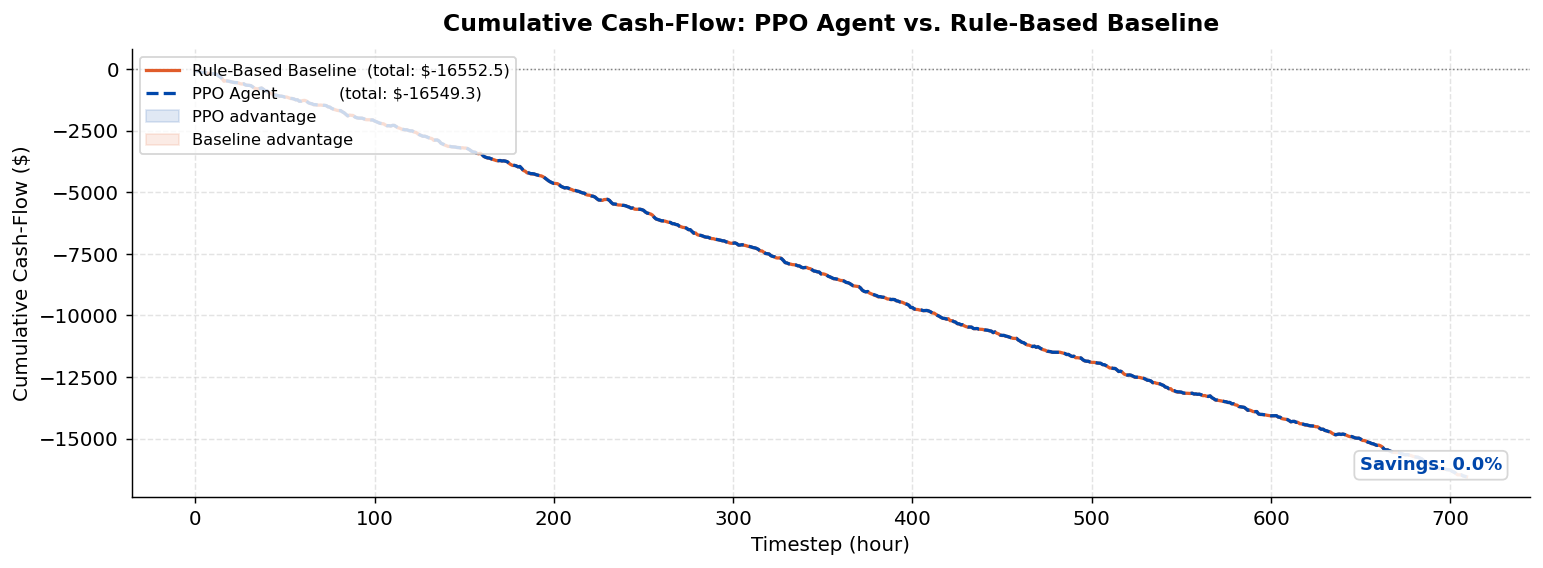

   ↳ G-1 saved: G1_financial_comparison.png


In [ ]:
# ── G-1  Cumulative financial comparison ─────────────────────
fig1, ax = plt.subplots(figsize=(12, 4.5))
steps = np.arange(len(baseline_cumsum))
ax.plot(steps, baseline_cumsum, color=C_BASE, lw=1.8,
        label=f"Rule-Based Baseline  (total: ${baseline_total:.1f})")
ax.plot(steps, ppo_cumsum,      color=C_PPO,  lw=1.8, ls="--",
        label=f"PPO Agent            (total: ${ppo_total:.1f})")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.fill_between(steps, baseline_cumsum, ppo_cumsum,
                where=(ppo_cumsum > baseline_cumsum),
                alpha=0.12, color=C_PPO, label="PPO advantage")
ax.fill_between(steps, baseline_cumsum, ppo_cumsum,
                where=(ppo_cumsum < baseline_cumsum),
                alpha=0.12, color=C_BASE, label="Baseline advantage")
ax.set_title("Cumulative Cash-Flow: PPO Agent vs. Rule-Based Baseline",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Timestep (hour)"); ax.set_ylabel("Cumulative Cash-Flow ($)")
ax.legend(loc="upper left", fontsize=9, framealpha=0.8)
ax.annotate(f"Savings: {savings_pct:.1f}%",
            xy=(0.98, 0.06), xycoords="axes fraction", ha="right",
            fontsize=10, fontweight="bold",
            color=C_PPO if savings_pct >= 0 else C_BASE,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.9))
fig1.tight_layout()
fig1.savefig("G1_financial_comparison.png", bbox_inches="tight")
plt.show()
print("   ↳ G-1 saved: G1_financial_comparison.png")


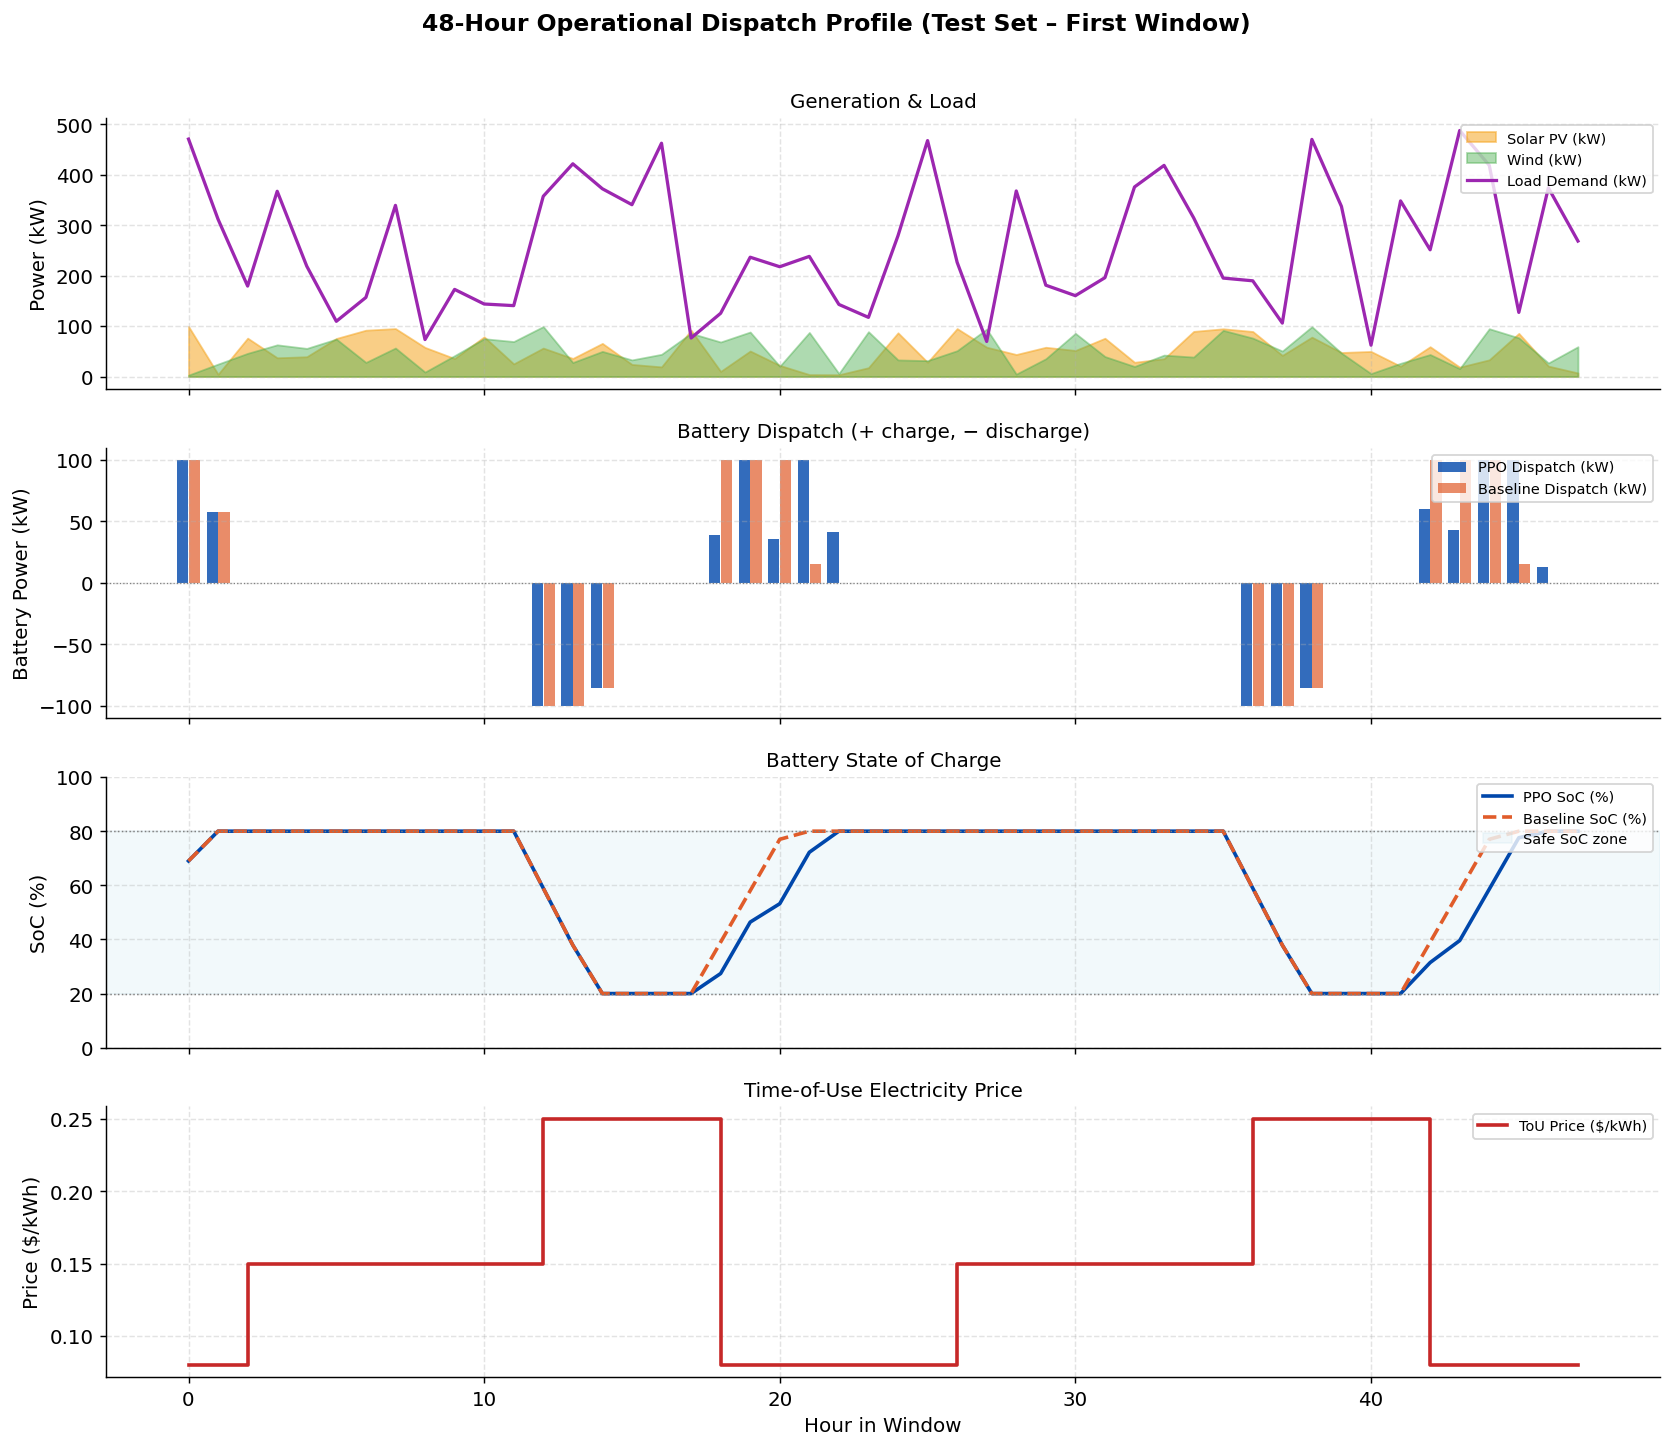

   ↳ G-2 saved: G2_dispatch_profile.png


In [ ]:
# ── G-2  48-hour operational dispatch window ─────────────────
WINDOW = 48
idx    = slice(0, WINDOW)
test_slice   = df_test.iloc[idx].reset_index(drop=True)
soc_ppo_win  = ppo_res["soc_hist"][idx]
soc_base_win = baseline_res["soc_hist"][idx]
bat_base_win = baseline_res["bat_hist"][idx]
price_win    = test_slice["price_actual"].values
x = np.arange(WINDOW)

fig2, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
fig2.suptitle("48-Hour Operational Dispatch Profile (Test Set – First Window)",
              fontsize=13, fontweight="bold", y=1.01)

ax1 = axes[0]
ax1.fill_between(x, test_slice["solar_pv_output"],  alpha=0.55, color=C_SOLAR, label="Solar PV (kW)")
ax1.fill_between(x, test_slice["wind_power_output"], alpha=0.45, color=C_WIND,  label="Wind (kW)")
ax1.plot(x, test_slice["grid_load_demand"], color=C_LOAD, lw=1.8, label="Load Demand (kW)")
ax1.set_ylabel("Power (kW)"); ax1.set_title("Generation & Load", fontsize=11)
ax1.legend(loc="upper right", fontsize=8)

ax2 = axes[1]
ax2.bar(x - 0.2, ppo_res["bat_hist"][idx], width=0.38, color=C_PPO,  alpha=0.8, label="PPO Dispatch (kW)")
ax2.bar(x + 0.2, bat_base_win,             width=0.38, color=C_BASE, alpha=0.7, label="Baseline Dispatch (kW)")
ax2.axhline(0, color="gray", lw=0.7, ls=":")
ax2.set_ylabel("Battery Power (kW)"); ax2.set_title("Battery Dispatch (+ charge, − discharge)", fontsize=11)
ax2.legend(loc="upper right", fontsize=8)

ax3 = axes[2]
ax3.plot(x, np.array(soc_ppo_win)  * 100, color=C_PPO,  lw=2, label="PPO SoC (%)")
ax3.plot(x, np.array(soc_base_win) * 100, color=C_BASE, lw=2, ls="--", label="Baseline SoC (%)")
ax3.axhspan(20, 80, color="lightblue", alpha=0.15, label="Safe SoC zone")
ax3.axhline(20, color="gray", lw=0.8, ls=":"); ax3.axhline(80, color="gray", lw=0.8, ls=":")
ax3.set_ylim(0, 100); ax3.set_ylabel("SoC (%)")
ax3.set_title("Battery State of Charge", fontsize=11); ax3.legend(loc="upper right", fontsize=8)

ax4 = axes[3]
ax4.step(x, price_win, color=C_PRICE, lw=2, where="post", label="ToU Price ($/kWh)")
ax4.set_ylabel("Price ($/kWh)"); ax4.set_xlabel("Hour in Window")
ax4.set_title("Time-of-Use Electricity Price", fontsize=11); ax4.legend(loc="upper right", fontsize=8)

fig2.tight_layout()
fig2.savefig("G2_dispatch_profile.png", bbox_inches="tight")
plt.show()
print("   ↳ G-2 saved: G2_dispatch_profile.png")


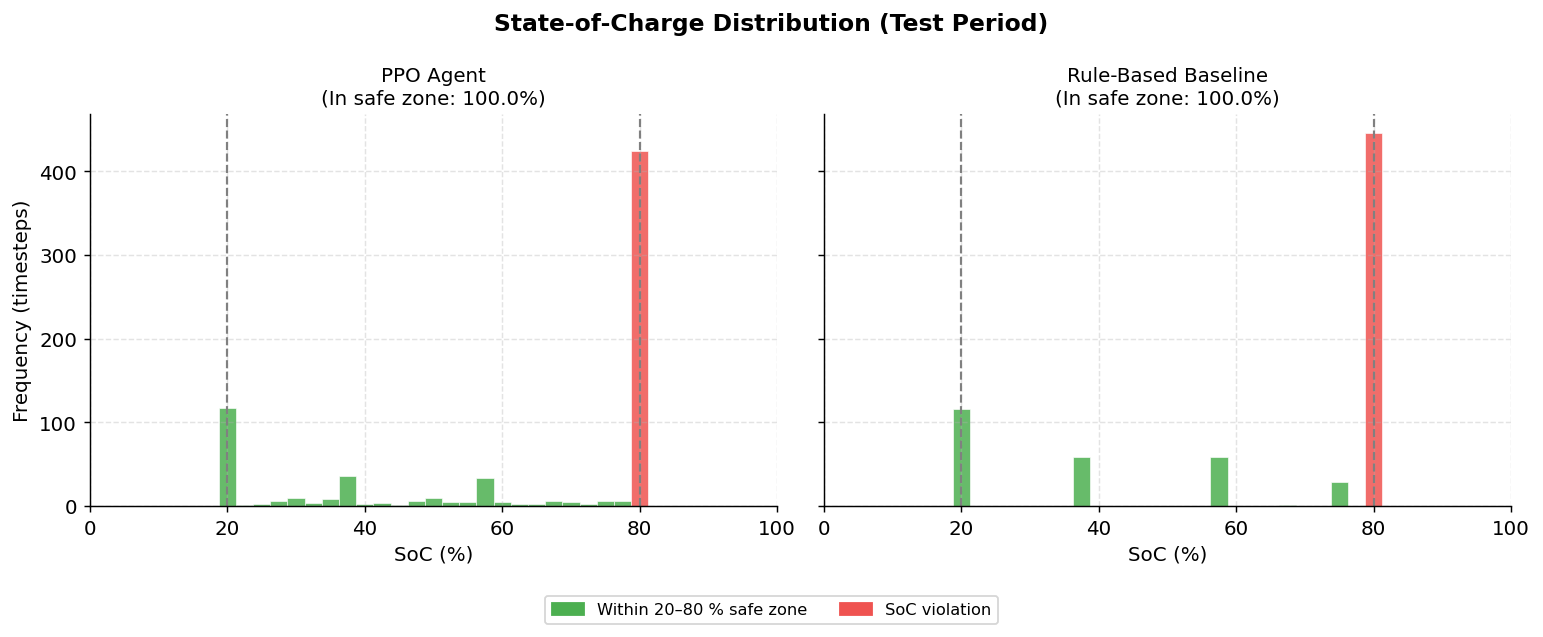

   ↳ G-3 saved: G3_soc_distribution.png

✅  Block G complete – all visualisations generated.


In [ ]:
# ── G-3  SoC Distribution Histogram ─────────────────────────
soc_ppo_pct  = np.array(ppo_res["soc_hist"])        * 100
soc_base_pct = np.array(baseline_res["soc_hist"])   * 100

in_zone_ppo  = np.mean((soc_ppo_pct  >= 20) & (soc_ppo_pct  <= 80)) * 100
in_zone_base = np.mean((soc_base_pct >= 20) & (soc_base_pct <= 80)) * 100

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
fig3.suptitle("State-of-Charge Distribution (Test Period)", fontsize=13, fontweight="bold")

for ax_h, soc_data, label, in_zone in zip(
    axes3,
    [soc_ppo_pct, soc_base_pct],
    ["PPO Agent", "Rule-Based Baseline"],
    [in_zone_ppo, in_zone_base],
):
    bins = np.linspace(0, 100, 41)
    counts, edges = np.histogram(soc_data, bins=bins)
    bar_colors = [
        "#4CAF50" if (edges[i] >= 20 and edges[i+1] <= 80) else "#EF5350"
        for i in range(len(counts))
    ]
    ax_h.bar(edges[:-1], counts, width=np.diff(edges),
             color=bar_colors, alpha=0.85, edgecolor="white", linewidth=0.4)
    ax_h.axvline(20, color="gray", lw=1.2, ls="--")
    ax_h.axvline(80, color="gray", lw=1.2, ls="--")
    ax_h.set_title(f"{label}\n(In safe zone: {in_zone:.1f}%)", fontsize=11)
    ax_h.set_xlabel("SoC (%)")
    ax_h.set_xlim(0, 100)

axes3[0].set_ylabel("Frequency (timesteps)")
safe_patch = mpatches.Patch(color="#4CAF50", label="Within 20–80 % safe zone")
viol_patch = mpatches.Patch(color="#EF5350", label="SoC violation")
fig3.legend(handles=[safe_patch, viol_patch],
            loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.08))
fig3.tight_layout()
fig3.savefig("G3_soc_distribution.png", bbox_inches="tight")
plt.show()
print("   ↳ G-3 saved: G3_soc_distribution.png")

print("\n✅  Block G complete – all visualisations generated.")


## 🏁 Final Results Summary

In [ ]:
print("\n" + "="*55)
print("  🏁  FINAL RESULTS")
print("="*55)
print(f"  Rule-Based Baseline cash-flow : ${baseline_total:>10.2f}")
print(f"  PPO Agent cash-flow           : ${ppo_total:>10.2f}")
if savings_pct >= 0:
    print(f"  ✅ PPO saved {savings_pct:.2f}% compared to baseline.")
else:
    print(f"  ⚠️  PPO underperformed baseline by {abs(savings_pct):.2f}%.")
    print("     Consider more training steps or reward tuning.")
print(f"  SoC in safe zone – PPO      : {in_zone_ppo:.1f}%")
print(f"  SoC in safe zone – Baseline : {in_zone_base:.1f}%")
print("="*55)



  🏁  FINAL RESULTS
  Rule-Based Baseline cash-flow : $ -16552.52
  PPO Agent cash-flow           : $ -16549.28
  ✅ PPO saved 0.02% compared to baseline.
  SoC in safe zone – PPO      : 100.0%
  SoC in safe zone – Baseline : 100.0%
